# Análise Paramétrica das Variáveis

Este notebook realiza uma análise paramétrica completa de todas as variáveis do dataset de treino, incluindo:
- Testes de normalidade (Shapiro-Wilk e Kolmogorov-Smirnov)
- Teste t de Student (comparando grupos por target)
- Valores p e significância estatística
- Visualizações e interpretações

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, normaltest, ttest_ind, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

Carregando o dataset de treino para análise paramétrica.

In [2]:
# Carregar dados de treino
df_treino = pd.read_csv('../data/processed/df_treino.csv')

print(f"Shape do dataset: {df_treino.shape}")
print(f"\nPrimeiras linhas:")
df_treino.head()

Shape do dataset: (25001186, 21)

Primeiras linhas:


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
0,2022-09-01,143137,835A3E1E0,143137,835A3E1E0,417.3800,Mexican Peso,417.3800,Mexican Peso,Reinvestment,0,Mexico Bank #50,143137,835A3E1E0,2AA22FC6990,Corporation #126451,Mexico Bank #50,143137,835A3E1E0,2AA22FC6990,Corporation #126451
1,2022-09-01,362692,81C920DA0,362692,81C920DA0,10370.3500,US Dollar,10370.3500,US Dollar,Reinvestment,0,Flagstone Trust Bank,362692,81C920DA0,2AA234A1D80,Partnership #10270,Flagstone Trust Bank,362692,81C920DA0,2AA234A1D80,Partnership #10270
2,2022-09-01,2120929,84346D460,2120929,84346D460,386382.5500,US Dollar,386382.5500,US Dollar,Reinvestment,0,National Bank of Newbury,2120929,84346D460,2AA20F1E430,Corporation #53588,National Bank of Newbury,2120929,84346D460,2AA20F1E430,Corporation #53588
3,2022-09-01,67054,81C91D960,67054,81C91D960,1955198.2500,US Dollar,1955198.2500,US Dollar,Reinvestment,0,First Bank of Los Angeles,67054,81C91D960,2AA20AA72E0,Partnership #31123,First Bank of Los Angeles,67054,81C91D960,2AA20AA72E0,Partnership #31123
4,2022-09-01,175944,841243680,175944,841243680,198525.2500,Swiss Franc,198525.2500,Swiss Franc,Reinvestment,0,Switzerland Bank #16,175944,841243680,2AA233762A0,Sole Proprietorship #138109,Switzerland Bank #16,175944,841243680,2AA233762A0,Sole Proprietorship #138109


In [3]:
# Informações sobre o dataset
print("Informações das colunas:")
print(df_treino.info())
print("\n" + "="*80)
print("\nEstatísticas descritivas:")
df_treino.describe()

Informações das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25001186 entries, 0 to 25001185
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   From Account        object 
 3   To Bank             int64  
 4   To Account          object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
 11  From Bank Name      object 
 12  Bank ID             int64  
 13  Account Number      object 
 14  From Entity ID      object 
 15  From Entity Name    object 
 16  To Bank Name        object 
 17  Bank ID_To          int64  
 18  Account Number_To   object 
 19  To Entity ID        object 
 20  To Entity Name      object 
dtypes: float64(2), int64(5), object(14)
memory usage: 3.9+ GB
None


Estatísticas descritivas:


,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Bank ID,Bank ID_To
count,25001186.0000,25001186.0000,25001186.0000,25001186.0000,25001186.0000,25001186.0000,25001186.0000
mean,275477.6200,392518.7870,7865921.2383,5318006.4280,0.0005,275477.6200,392518.7870
std,590083.3047,637767.6410,1790779410.9695,1309452151.7505,0.0221,590083.3047,637767.6410
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,2695.0000,28596.0000,194.9800,196.2800,0.0000,2695.0000,28596.0000
50%,44763.0000,143136.0000,1416.7100,1419.7700,0.0000,44763.0000,143136.0000
75%,211537.0000,249693.0000,11867.0500,11789.9600,0.0000,211537.0000,249693.0000
max,3219766.0000,3219766.0000,2020628026922.1101,2020628026922.1101,1.0000,3219766.0000,3219766.0000


## 2. Identificação das Variáveis

Separando as variáveis numéricas e identificando a variável target.

In [4]:
# Identificar variáveis numéricas
numeric_cols = df_treino.select_dtypes(include=[np.number]).columns.tolist()

# Identificar possível variável target
# Geralmente é 'is_laundering', 'flag', 'target', ou similar
possible_targets = ['is_laundering', 'flag', 'target', 'label', 'is_fraud']
target_col = None

for col in possible_targets:
    if col in df_treino.columns:
        target_col = col
        break

# Se não encontrar, procurar coluna binária
if target_col is None:
    for col in numeric_cols:
        if df_treino[col].nunique() == 2 and set(df_treino[col].unique()).issubset({0, 1}):
            target_col = col
            break

print(f"Variável target identificada: {target_col}")
print(f"Total de variáveis numéricas: {len(numeric_cols)}")
print(f"\nVariáveis numéricas:")
for i, col in enumerate(numeric_cols, 1):
    print(f"{i}. {col}")

Variável target identificada: Is Laundering
Total de variáveis numéricas: 7

Variáveis numéricas:
1. From Bank
2. To Bank
3. Amount Received
4. Amount Paid
5. Is Laundering
6. Bank ID
7. Bank ID_To


In [5]:
# Remover target das variáveis a serem testadas
if target_col and target_col in numeric_cols:
    feature_cols = [col for col in numeric_cols if col != target_col]
else:
    feature_cols = numeric_cols.copy()

print(f"Variáveis para análise (excluindo target): {len(feature_cols)}")

# Verificar distribuição do target
if target_col:
    print(f"\nDistribuição da variável target '{target_col}':")
    print(df_treino[target_col].value_counts())
    print(f"\nProporção:")
    print(df_treino[target_col].value_counts(normalize=True))

Variáveis para análise (excluindo target): 6

Distribuição da variável target 'Is Laundering':
Is Laundering
0    24988928
1       12258
Name: count, dtype: int64

Proporção:
Is Laundering
0   0.9995
1   0.0005
Name: proportion, dtype: float64


## 3. Testes de Normalidade

Testando a normalidade de todas as variáveis usando:
- **Shapiro-Wilk Test**: Ideal para amostras pequenas (n < 5000)
- **Kolmogorov-Smirnov Test**: Melhor para amostras grandes
- **Anderson-Darling Test**: Testa normalidade com mais peso nas caudas

**Interpretação**: 
- H0 (hipótese nula): Os dados seguem uma distribuição normal
- Se p-value < 0.05: Rejeitamos H0 (dados NÃO são normais)
- Se p-value >= 0.05: Não rejeitamos H0 (dados podem ser normais)

In [6]:
def test_normality(data, column_name, sample_size=5000):
    """
    Realiza múltiplos testes de normalidade em uma variável.
    
    Parameters:
    -----------
    data : array-like
        Dados a serem testados
    column_name : str
        Nome da coluna
    sample_size : int
        Tamanho da amostra para testes (para datasets grandes)
    
    Returns:
    --------
    dict : Dicionário com resultados dos testes
    """
    # Remover NaN
    clean_data = data.dropna()
    
    if len(clean_data) == 0:
        return {
            'variable': column_name,
            'n_obs': 0,
            'shapiro_stat': np.nan,
            'shapiro_pvalue': np.nan,
            'ks_stat': np.nan,
            'ks_pvalue': np.nan,
            'normal_shapiro': 'No data',
            'normal_ks': 'No data'
        }
    
    # Se o dataset for muito grande, usar amostra
    if len(clean_data) > sample_size:
        sample_data = clean_data.sample(n=sample_size, random_state=42)
    else:
        sample_data = clean_data
    
    # Shapiro-Wilk Test (limitado a 5000 observações)
    try:
        shapiro_stat, shapiro_p = shapiro(sample_data)
    except:
        shapiro_stat, shapiro_p = np.nan, np.nan
    
    # Kolmogorov-Smirnov Test
    try:
        # Normalizar os dados
        normalized = (sample_data - sample_data.mean()) / sample_data.std()
        ks_stat, ks_p = kstest(normalized, 'norm')
    except:
        ks_stat, ks_p = np.nan, np.nan
    
    return {
        'variable': column_name,
        'n_obs': len(clean_data),
        'shapiro_stat': shapiro_stat,
        'shapiro_pvalue': shapiro_p,
        'ks_stat': ks_stat,
        'ks_pvalue': ks_p,
        'normal_shapiro': 'Yes' if shapiro_p >= 0.05 else 'No',
        'normal_ks': 'Yes' if ks_p >= 0.05 else 'No'
    }

print("Função de teste de normalidade criada!")

Função de teste de normalidade criada!


In [7]:
# Aplicar teste de normalidade em todas as variáveis
print("Executando testes de normalidade...")
print("Isso pode levar alguns minutos para datasets grandes...\n")

normality_results = []
for i, col in enumerate(feature_cols, 1):
    if i % 10 == 0:
        print(f"Processando variável {i}/{len(feature_cols)}...")
    
    result = test_normality(df_treino[col], col)
    normality_results.append(result)

# Criar DataFrame com resultados
df_normality = pd.DataFrame(normality_results)

print(f"\nTestes de normalidade concluídos para {len(feature_cols)} variáveis!")
print(f"\nPrimeiros resultados:")
df_normality.head(10)

Executando testes de normalidade...
Isso pode levar alguns minutos para datasets grandes...


Testes de normalidade concluídos para 6 variáveis!

Primeiros resultados:


,variable,n_obs,shapiro_stat,shapiro_pvalue,ks_stat,ks_pvalue,normal_shapiro,normal_ks
0,From Bank,25001186,0.4863,0.0000,0.3506,0.0000,No,No
1,To Bank,25001186,0.6011,0.0000,0.3743,0.0000,No,No
2,Amount Received,25001186,0.0210,0.0000,0.4818,0.0000,No,No
3,Amount Paid,25001186,0.0180,0.0000,0.4833,0.0000,No,No
4,Bank ID,25001186,0.4863,0.0000,0.3506,0.0000,No,No
5,Bank ID_To,25001186,0.6011,0.0000,0.3743,0.0000,No,No


In [8]:
# Resumo dos testes de normalidade
print("="*80)
print("RESUMO DOS TESTES DE NORMALIDADE")
print("="*80)

print("\n1. Estatísticas gerais:")
print(f"   - Total de variáveis testadas: {len(df_normality)}")
print(f"   - Variáveis normais (Shapiro-Wilk, p>=0.05): {(df_normality['normal_shapiro'] == 'Yes').sum()}")
print(f"   - Variáveis normais (Kolmogorov-Smirnov, p>=0.05): {(df_normality['normal_ks'] == 'Yes').sum()}")

print("\n2. Top 10 variáveis mais próximas da normalidade (por Shapiro-Wilk p-value):")
df_normality_sorted = df_normality.sort_values('shapiro_pvalue', ascending=False)
print(df_normality_sorted[['variable', 'shapiro_pvalue', 'ks_pvalue', 'normal_shapiro', 'normal_ks']].head(10))

print("\n3. Top 10 variáveis mais distantes da normalidade (por Shapiro-Wilk p-value):")
print(df_normality_sorted[['variable', 'shapiro_pvalue', 'ks_pvalue', 'normal_shapiro', 'normal_ks']].tail(10))

RESUMO DOS TESTES DE NORMALIDADE

1. Estatísticas gerais:
   - Total de variáveis testadas: 6
   - Variáveis normais (Shapiro-Wilk, p>=0.05): 0
   - Variáveis normais (Kolmogorov-Smirnov, p>=0.05): 0

2. Top 10 variáveis mais próximas da normalidade (por Shapiro-Wilk p-value):
          variable  shapiro_pvalue  ks_pvalue normal_shapiro normal_ks
1          To Bank          0.0000     0.0000             No        No
5       Bank ID_To          0.0000     0.0000             No        No
0        From Bank          0.0000     0.0000             No        No
4          Bank ID          0.0000     0.0000             No        No
2  Amount Received          0.0000     0.0000             No        No
3      Amount Paid          0.0000     0.0000             No        No

3. Top 10 variáveis mais distantes da normalidade (por Shapiro-Wilk p-value):
          variable  shapiro_pvalue  ks_pvalue normal_shapiro normal_ks
1          To Bank          0.0000     0.0000             No        No
5   

## 4. Teste T de Student

Comparando as médias de cada variável entre os dois grupos (target = 0 vs target = 1).

**Interpretação**:
- H0: As médias dos dois grupos são iguais
- Se p-value < 0.05: Rejeitamos H0 (as médias são significativamente diferentes)
- Se p-value >= 0.05: Não rejeitamos H0 (não há diferença significativa)

**Nota**: Se os dados não forem normais, também será aplicado o teste não-paramétrico de Mann-Whitney U.

In [9]:
def perform_ttest(df, column_name, target_column):
    """
    Realiza teste t de Student e Mann-Whitney U test comparando dois grupos.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame com os dados
    column_name : str
        Nome da variável a ser testada
    target_column : str
        Nome da variável target (binária)
    
    Returns:
    --------
    dict : Dicionário com resultados dos testes
    """
    # Separar os grupos
    group_0 = df[df[target_column] == 0][column_name].dropna()
    group_1 = df[df[target_column] == 1][column_name].dropna()
    
    if len(group_0) == 0 or len(group_1) == 0:
        return {
            'variable': column_name,
            'n_group_0': len(group_0),
            'n_group_1': len(group_1),
            'mean_group_0': np.nan,
            'mean_group_1': np.nan,
            'std_group_0': np.nan,
            'std_group_1': np.nan,
            'ttest_statistic': np.nan,
            'ttest_pvalue': np.nan,
            'mannwhitney_statistic': np.nan,
            'mannwhitney_pvalue': np.nan,
            'significant_ttest': 'No data',
            'significant_mannwhitney': 'No data'
        }
    
    # Calcular estatísticas descritivas
    mean_0 = group_0.mean()
    mean_1 = group_1.mean()
    std_0 = group_0.std()
    std_1 = group_1.std()
    
    # Teste t de Student
    try:
        t_stat, t_pvalue = ttest_ind(group_0, group_1, equal_var=False, nan_policy='omit')
    except:
        t_stat, t_pvalue = np.nan, np.nan
    
    # Mann-Whitney U test (alternativa não-paramétrica)
    try:
        mw_stat, mw_pvalue = mannwhitneyu(group_0, group_1, alternative='two-sided')
    except:
        mw_stat, mw_pvalue = np.nan, np.nan
    
    return {
        'variable': column_name,
        'n_group_0': len(group_0),
        'n_group_1': len(group_1),
        'mean_group_0': mean_0,
        'mean_group_1': mean_1,
        'std_group_0': std_0,
        'std_group_1': std_1,
        'ttest_statistic': t_stat,
        'ttest_pvalue': t_pvalue,
        'mannwhitney_statistic': mw_stat,
        'mannwhitney_pvalue': mw_pvalue,
        'significant_ttest': 'Yes' if t_pvalue < 0.05 else 'No',
        'significant_mannwhitney': 'Yes' if mw_pvalue < 0.05 else 'No'
    }

print("Função de teste t criada!")

Função de teste t criada!


In [10]:
# Aplicar teste t em todas as variáveis
if target_col:
    print("Executando testes t de Student e Mann-Whitney U...")
    print("Isso pode levar alguns minutos...\n")
    
    ttest_results = []
    for i, col in enumerate(feature_cols, 1):
        if i % 10 == 0:
            print(f"Processando variável {i}/{len(feature_cols)}...")
        
        result = perform_ttest(df_treino, col, target_col)
        ttest_results.append(result)
    
    # Criar DataFrame com resultados
    df_ttest = pd.DataFrame(ttest_results)
    
    print(f"\nTestes t concluídos para {len(feature_cols)} variáveis!")
    print(f"\nPrimeiros resultados:")
    df_ttest.head(10)
else:
    print("Variável target não identificada. Pulando testes t.")

Executando testes t de Student e Mann-Whitney U...
Isso pode levar alguns minutos...


Testes t concluídos para 6 variáveis!

Primeiros resultados:


In [11]:
# Resumo dos testes t
if target_col and 'df_ttest' in locals():
    print("="*80)
    print("RESUMO DOS TESTES T")
    print("="*80)
    
    print("\n1. Estatísticas gerais:")
    print(f"   - Total de variáveis testadas: {len(df_ttest)}")
    print(f"   - Variáveis significativas (t-test, p<0.05): {(df_ttest['significant_ttest'] == 'Yes').sum()}")
    print(f"   - Variáveis significativas (Mann-Whitney, p<0.05): {(df_ttest['significant_mannwhitney'] == 'Yes').sum()}")
    
    print("\n2. Top 10 variáveis com maior diferença entre grupos (menor p-value do t-test):")
    df_ttest_sorted = df_ttest.sort_values('ttest_pvalue')
    print(df_ttest_sorted[['variable', 'mean_group_0', 'mean_group_1', 'ttest_pvalue', 'significant_ttest']].head(10))
    
    print("\n3. Top 10 variáveis sem diferença significativa entre grupos (maior p-value do t-test):")
    print(df_ttest_sorted[['variable', 'mean_group_0', 'mean_group_1', 'ttest_pvalue', 'significant_ttest']].tail(10))

RESUMO DOS TESTES T

1. Estatísticas gerais:
   - Total de variáveis testadas: 6
   - Variáveis significativas (t-test, p<0.05): 6
   - Variáveis significativas (Mann-Whitney, p<0.05): 6

2. Top 10 variáveis com maior diferença entre grupos (menor p-value do t-test):
          variable  mean_group_0  mean_group_1  ttest_pvalue significant_ttest
0        From Bank   275503.3416   223041.9150        0.0000               Yes
4          Bank ID   275503.3416   223041.9150        0.0000               Yes
5       Bank ID_To   392547.2771   334439.3702        0.0000               Yes
1          To Bank   392547.2771   334439.3702        0.0000               Yes
3      Amount Paid  5307588.6299 26555533.3693        0.0082               Yes
2  Amount Received  7856753.2874 26555533.3693        0.0200               Yes

3. Top 10 variáveis sem diferença significativa entre grupos (maior p-value do t-test):
          variable  mean_group_0  mean_group_1  ttest_pvalue significant_ttest
0        Fr

## 5. Análise Consolidada

Combinando os resultados de normalidade e testes t para uma visão completa.

In [12]:
# Merge dos resultados
if target_col and 'df_ttest' in locals():
    df_parametric_analysis = pd.merge(
        df_normality,
        df_ttest,
        on='variable',
        how='inner'
    )
    
    # Reordenar colunas para melhor visualização
    cols_order = [
        'variable',
        'n_obs',
        'n_group_0',
        'n_group_1',
        'mean_group_0',
        'mean_group_1',
        'std_group_0',
        'std_group_1',
        'shapiro_pvalue',
        'ks_pvalue',
        'normal_shapiro',
        'normal_ks',
        'ttest_statistic',
        'ttest_pvalue',
        'mannwhitney_pvalue',
        'significant_ttest',
        'significant_mannwhitney'
    ]
    
    df_parametric_analysis = df_parametric_analysis[cols_order]
    
    print("Análise Paramétrica Consolidada")
    print("="*80)
    print(f"Total de variáveis analisadas: {len(df_parametric_analysis)}")
    print("\nPrimeiras 10 variáveis:")
    df_parametric_analysis.head(10)
else:
    df_parametric_analysis = df_normality
    print("Análise apenas de normalidade (target não disponível)")

Análise Paramétrica Consolidada
Total de variáveis analisadas: 6

Primeiras 10 variáveis:


In [13]:
# Variáveis mais discriminativas (menores p-values no teste t)
if target_col and 'df_parametric_analysis' in locals():
    print("\n" + "="*80)
    print("VARIÁVEIS MAIS DISCRIMINATIVAS")
    print("="*80)
    print("\nTop 20 variáveis com maior poder discriminativo (menor p-value):\n")
    
    top_vars = df_parametric_analysis.nsmallest(20, 'ttest_pvalue')
    display_cols = ['variable', 'mean_group_0', 'mean_group_1', 'ttest_pvalue', 
                    'normal_shapiro', 'significant_ttest']
    print(top_vars[display_cols].to_string(index=False))


VARIÁVEIS MAIS DISCRIMINATIVAS

Top 20 variáveis com maior poder discriminativo (menor p-value):

       variable  mean_group_0  mean_group_1  ttest_pvalue normal_shapiro significant_ttest
      From Bank   275503.3416   223041.9150        0.0000             No               Yes
        Bank ID   275503.3416   223041.9150        0.0000             No               Yes
     Bank ID_To   392547.2771   334439.3702        0.0000             No               Yes
        To Bank   392547.2771   334439.3702        0.0000             No               Yes
    Amount Paid  5307588.6299 26555533.3693        0.0082             No               Yes
Amount Received  7856753.2874 26555533.3693        0.0200             No               Yes


## 6. Visualizações

Criando visualizações para melhor compreensão dos resultados.

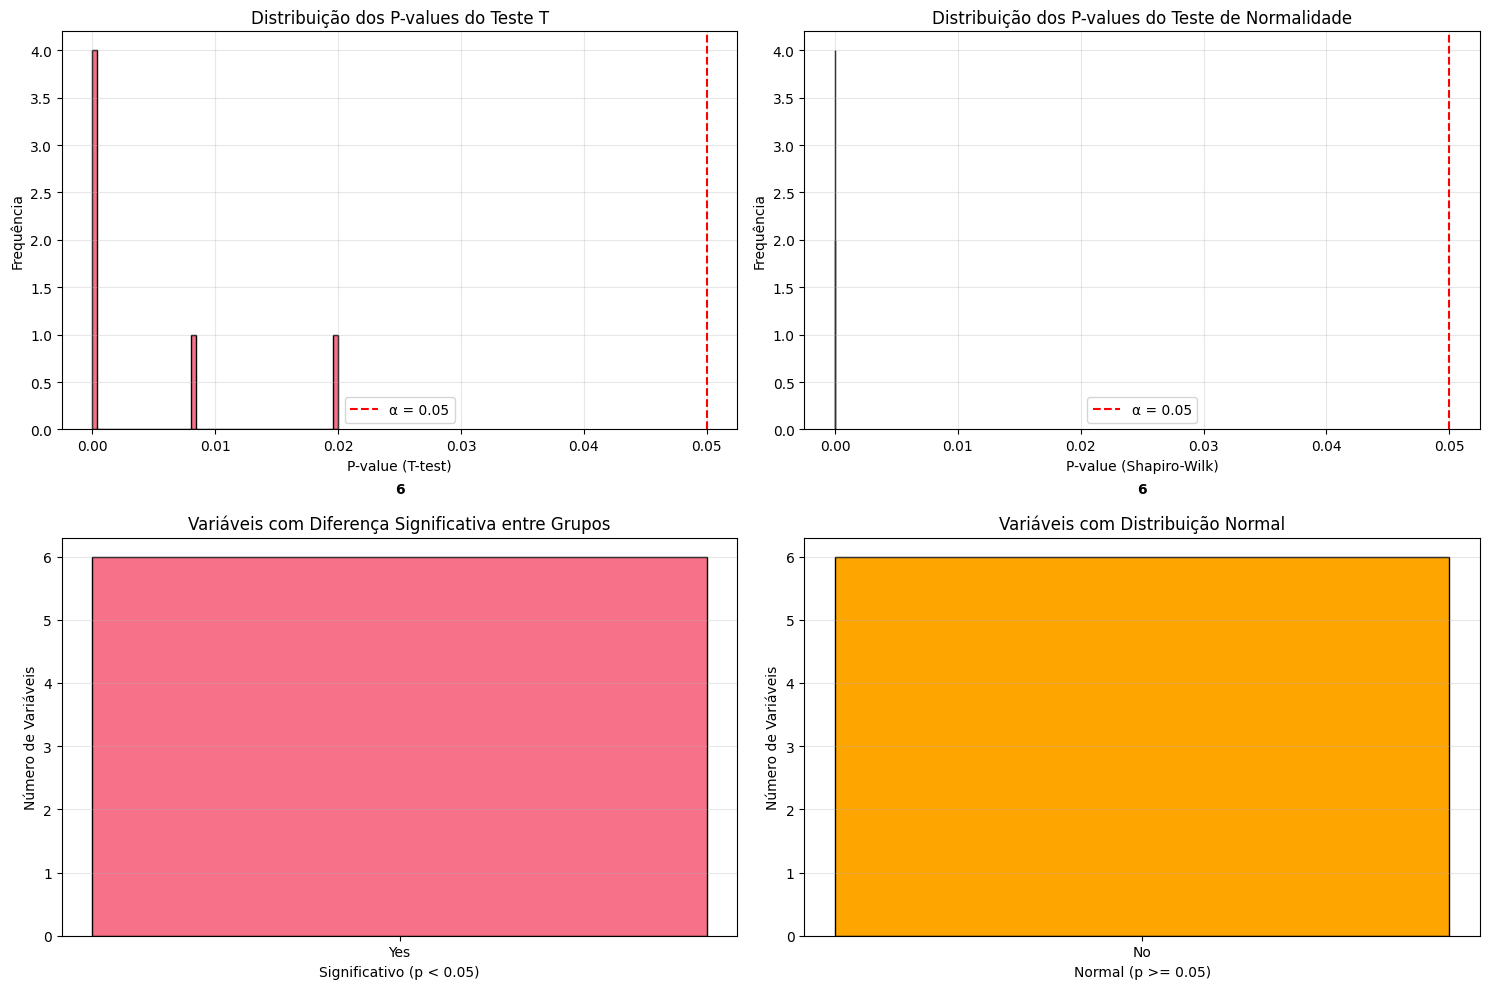

In [14]:
# Distribuição dos p-values
if target_col and 'df_parametric_analysis' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Histograma dos p-values do teste t
    axes[0, 0].hist(df_parametric_analysis['ttest_pvalue'].dropna(), bins=50, edgecolor='black')
    axes[0, 0].axvline(0.05, color='red', linestyle='--', label='α = 0.05')
    axes[0, 0].set_xlabel('P-value (T-test)')
    axes[0, 0].set_ylabel('Frequência')
    axes[0, 0].set_title('Distribuição dos P-values do Teste T')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # 2. Histograma dos p-values do Shapiro-Wilk
    axes[0, 1].hist(df_parametric_analysis['shapiro_pvalue'].dropna(), bins=50, edgecolor='black')
    axes[0, 1].axvline(0.05, color='red', linestyle='--', label='α = 0.05')
    axes[0, 1].set_xlabel('P-value (Shapiro-Wilk)')
    axes[0, 1].set_ylabel('Frequência')
    axes[0, 1].set_title('Distribuição dos P-values do Teste de Normalidade')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # 3. Proporção de variáveis significativas
    sig_counts = df_parametric_analysis['significant_ttest'].value_counts()
    axes[1, 0].bar(sig_counts.index, sig_counts.values, edgecolor='black')
    axes[1, 0].set_xlabel('Significativo (p < 0.05)')
    axes[1, 0].set_ylabel('Número de Variáveis')
    axes[1, 0].set_title('Variáveis com Diferença Significativa entre Grupos')
    axes[1, 0].grid(alpha=0.3, axis='y')
    for i, v in enumerate(sig_counts.values):
        axes[1, 0].text(i, v + 1, str(v), ha='center', fontweight='bold')
    
    # 4. Proporção de variáveis normais
    normal_counts = df_parametric_analysis['normal_shapiro'].value_counts()
    axes[1, 1].bar(normal_counts.index, normal_counts.values, edgecolor='black', color='orange')
    axes[1, 1].set_xlabel('Normal (p >= 0.05)')
    axes[1, 1].set_ylabel('Número de Variáveis')
    axes[1, 1].set_title('Variáveis com Distribuição Normal')
    axes[1, 1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(normal_counts.values):
        axes[1, 1].text(i, v + 1, str(v), ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Gráficos requerem variável target.")

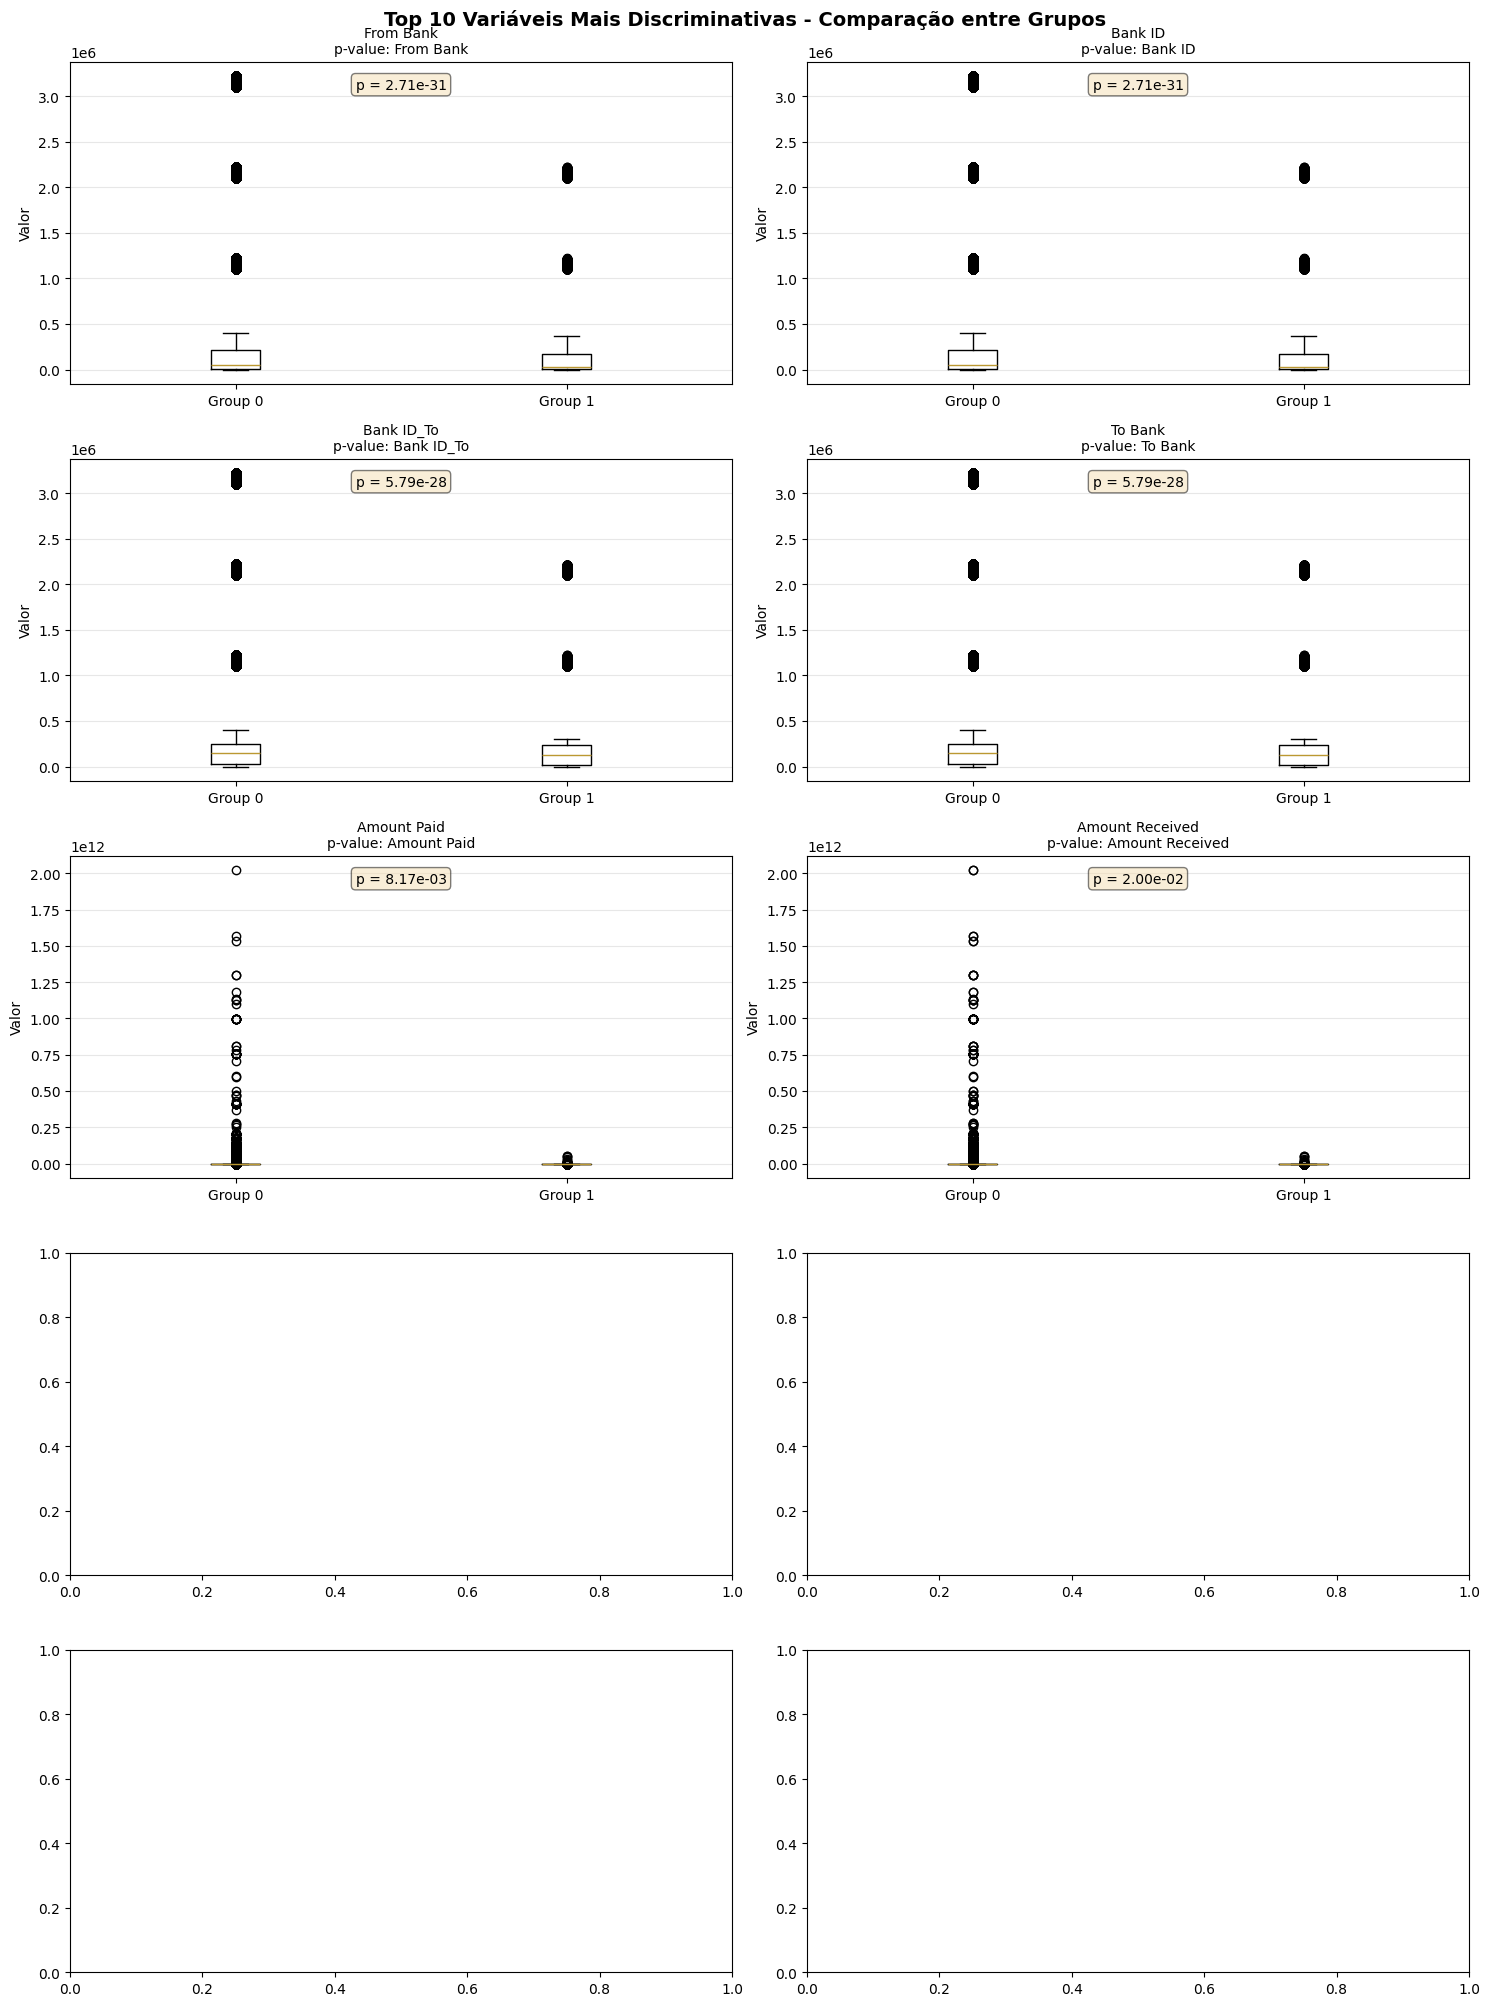

In [15]:
# Top 10 variáveis mais discriminativas - Comparação visual
if target_col and 'df_parametric_analysis' in locals():
    top_10_vars = df_parametric_analysis.nsmallest(10, 'ttest_pvalue')['variable'].tolist()
    
    fig, axes = plt.subplots(5, 2, figsize=(15, 20))
    axes = axes.ravel()
    
    for i, var in enumerate(top_10_vars):
        # Dados dos dois grupos
        data_0 = df_treino[df_treino[target_col] == 0][var].dropna()
        data_1 = df_treino[df_treino[target_col] == 1][var].dropna()
        
        # Boxplot comparativo
        axes[i].boxplot([data_0, data_1], labels=['Group 0', 'Group 1'])
        axes[i].set_title(f'{var}\np-value: {top_10_vars[i]:}', fontsize=10)
        axes[i].set_ylabel('Valor')
        axes[i].grid(alpha=0.3, axis='y')
        
        # Adicionar p-value
        pval = df_parametric_analysis[df_parametric_analysis['variable'] == var]['ttest_pvalue'].values[0]
        axes[i].text(0.5, 0.95, f'p = {pval:.2e}', 
                    transform=axes[i].transAxes, 
                    ha='center', va='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.suptitle('Top 10 Variáveis Mais Discriminativas - Comparação entre Grupos', 
                 fontsize=14, fontweight='bold', y=1.001)
    plt.show()
else:
    print("Gráfico requer variável target.")

## 7. Exportar Resultados

Salvando os resultados da análise paramétrica para uso posterior.

In [16]:
# Exportar resultados
output_path = '../data/processed/parametric_analysis_results.csv'
df_parametric_analysis.to_csv(output_path, index=False)
print(f"Resultados salvos em: {output_path}")

# Criar um resumo executivo
print("\n" + "="*80)
print("RESUMO EXECUTIVO DA ANÁLISE PARAMÉTRICA")
print("="*80)

if target_col and 'df_parametric_analysis' in locals():
    total_vars = len(df_parametric_analysis)
    normal_vars = (df_parametric_analysis['normal_shapiro'] == 'Yes').sum()
    significant_vars = (df_parametric_analysis['significant_ttest'] == 'Yes').sum()
    
    print(f"\n1. DADOS ANALISADOS:")
    print(f"   - Total de variáveis: {total_vars}")
    print(f"   - Observações no grupo 0: {df_parametric_analysis['n_group_0'].iloc[0]:,.0f}")
    print(f"   - Observações no grupo 1: {df_parametric_analysis['n_group_1'].iloc[0]:,.0f}")
    
    print(f"\n2. NORMALIDADE:")
    print(f"   - Variáveis normais: {normal_vars} ({normal_vars/total_vars*100:.1f}%)")
    print(f"   - Variáveis não-normais: {total_vars - normal_vars} ({(total_vars-normal_vars)/total_vars*100:.1f}%)")
    
    print(f"\n3. DIFERENÇAS ENTRE GRUPOS (Teste T):")
    print(f"   - Variáveis significativas (p<0.05): {significant_vars} ({significant_vars/total_vars*100:.1f}%)")
    print(f"   - Variáveis não-significativas (p>=0.05): {total_vars - significant_vars} ({(total_vars-significant_vars)/total_vars*100:.1f}%)")
    
    print(f"\n4. TOP 5 VARIÁVEIS MAIS DISCRIMINATIVAS:")
    top5 = df_parametric_analysis.nsmallest(5, 'ttest_pvalue')
    for idx, row in top5.iterrows():
        print(f"   - {row['variable']}: p-value = {row['ttest_pvalue']:.2e}")
    
    print(f"\n5. RECOMENDAÇÕES:")
    if normal_vars / total_vars < 0.3:
        print("   - A maioria das variáveis não segue distribuição normal.")
        print("   - Considerar usar testes não-paramétricos ou transformações de dados.")
    
    if significant_vars / total_vars > 0.5:
        print(f"   - {significant_vars/total_vars*100:.1f}% das variáveis mostram diferença significativa entre grupos.")
        print("   - Há forte potencial discriminativo no dataset.")
    
    print("\n" + "="*80)

Resultados salvos em: ../data/processed/parametric_analysis_results.csv

RESUMO EXECUTIVO DA ANÁLISE PARAMÉTRICA

1. DADOS ANALISADOS:
   - Total de variáveis: 6
   - Observações no grupo 0: 24,988,928
   - Observações no grupo 1: 12,258

2. NORMALIDADE:
   - Variáveis normais: 0 (0.0%)
   - Variáveis não-normais: 6 (100.0%)

3. DIFERENÇAS ENTRE GRUPOS (Teste T):
   - Variáveis significativas (p<0.05): 6 (100.0%)
   - Variáveis não-significativas (p>=0.05): 0 (0.0%)

4. TOP 5 VARIÁVEIS MAIS DISCRIMINATIVAS:
   - From Bank: p-value = 2.71e-31
   - Bank ID: p-value = 2.71e-31
   - To Bank: p-value = 5.79e-28
   - Bank ID_To: p-value = 5.79e-28
   - Amount Paid: p-value = 8.17e-03

5. RECOMENDAÇÕES:
   - A maioria das variáveis não segue distribuição normal.
   - Considerar usar testes não-paramétricos ou transformações de dados.
   - 100.0% das variáveis mostram diferença significativa entre grupos.
   - Há forte potencial discriminativo no dataset.



## 8. Análise Detalhada de Variáveis Específicas

Você pode usar a célula abaixo para analisar variáveis específicas em detalhes.

In [17]:
def analyze_variable_detail(variable_name):
    """
    Análise detalhada de uma variável específica.
    """
    if variable_name not in df_treino.columns:
        print(f"Variável '{variable_name}' não encontrada no dataset.")
        return
    
    print("="*80)
    print(f"ANÁLISE DETALHADA: {variable_name}")
    print("="*80)
    
    # Estatísticas descritivas
    print("\n1. ESTATÍSTICAS DESCRITIVAS:")
    print(df_treino[variable_name].describe())
    
    # Informações da análise paramétrica
    if 'df_parametric_analysis' in locals() and variable_name in df_parametric_analysis['variable'].values:
        var_stats = df_parametric_analysis[df_parametric_analysis['variable'] == variable_name].iloc[0]
        
        print("\n2. TESTE DE NORMALIDADE:")
        print(f"   - Shapiro-Wilk p-value: {var_stats['shapiro_pvalue']:.4f}")
        print(f"   - Normal?: {var_stats['normal_shapiro']}")
        
        if target_col:
            print("\n3. TESTE T (Comparação entre grupos):")
            print(f"   - Média Grupo 0: {var_stats['mean_group_0']:.4f}")
            print(f"   - Média Grupo 1: {var_stats['mean_group_1']:.4f}")
            print(f"   - T-statistic: {var_stats['ttest_statistic']:.4f}")
            print(f"   - P-value: {var_stats['ttest_pvalue']:.4e}")
            print(f"   - Significativo?: {var_stats['significant_ttest']}")
    
    # Visualização
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Histograma
    axes[0].hist(df_treino[variable_name].dropna(), bins=50, edgecolor='black')
    axes[0].set_xlabel(variable_name)
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição')
    axes[0].grid(alpha=0.3)
    
    # Q-Q Plot
    from scipy import stats
    stats.probplot(df_treino[variable_name].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot (Normalidade)')
    axes[1].grid(alpha=0.3)
    
    # Boxplot por grupo (se houver target)
    if target_col:
        data_0 = df_treino[df_treino[target_col] == 0][variable_name].dropna()
        data_1 = df_treino[df_treino[target_col] == 1][variable_name].dropna()
        axes[2].boxplot([data_0, data_1], labels=['Group 0', 'Group 1'])
        axes[2].set_ylabel(variable_name)
        axes[2].set_title('Comparação entre Grupos')
        axes[2].grid(alpha=0.3, axis='y')
    else:
        axes[2].boxplot(df_treino[variable_name].dropna())
        axes[2].set_ylabel(variable_name)
        axes[2].set_title('Boxplot')
        axes[2].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

# Exemplo de uso:
# analyze_variable_detail('nome_da_variavel')